In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_simload
import jsm_mcmc
import jsm_stats
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg
import matplotlib.ticker as ticker

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [4]:
# test = jsm_ancillary.load_massspec_z0("../../data/vdb/N500/", "artificial", order="all")
# test.to_csv("../../data/vdb/N500/summary_tabs/artificial_all.csv")

In [5]:
# test = jsm_ancillary.load_massspec_z0("../../data/vdb/N500/", "artificial", order="k2")
# test.to_csv("../../data/vdb/N500/summary_tabs/artificial_k2.csv")

In [6]:
# test = jsm_ancillary.load_massspec_z0("../../data/vdb/N500/", "artificial", order="k3")
# test.to_csv("../../data/vdb/N500/summary_tabs/artificial_k3.csv")

In [7]:
kall = pd.read_csv("../../data/vdb/N500/summary_tabs/artificial_all.csv")
k1 = pd.read_csv("../../data/vdb/N500/summary_tabs/artificial_k1.csv")
k2 = pd.read_csv("../../data/vdb/N500/summary_tabs/artificial_k2.csv")
k3 = pd.read_csv("../../data/vdb/N500/summary_tabs/artificial_k3.csv")

In [8]:
kallnorm = jsm_simload.NormalizeData(kall, dataset_title="all orders")
k1norm = jsm_simload.NormalizeData(k1, dataset_title="k=1")
k2norm = jsm_simload.NormalizeData(k2, dataset_title="k=2")
k3norm = jsm_simload.NormalizeData(k3, dataset_title="k=2")

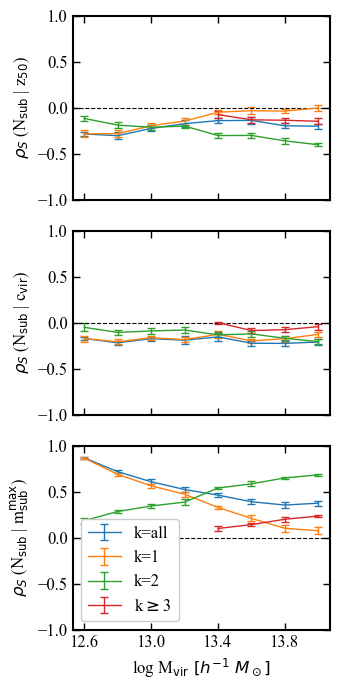

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(single_textwidth, double_textwidth), sharex=True, sharey=True)

datasets = [kallnorm, k1norm, k2norm, k3norm]
colors = ["C0", "C1", "C2", "C3"]
labelz = ["k=all", "k=1", "k=2", "k$\geq$3"]

for j, dataset in enumerate(datasets):
    for i in range(3):
        axes[i].errorbar(
            dataset.logMvir_bincenters, dataset.rho_mat[i], yerr=dataset.rho_err_mat[i], color=colors[j], capsize=3, lw=1, label=labelz[j])

axes[0].set_ylim(-1, 1)
axes[0].axhline(0, color="k", lw=0.8, ls="--")
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[2].axhline(0, color="k", lw=0.8, ls="--")
axes[2].set_xlabel("log M$_{\\rm vir}\ [h^{-1}\ M_\odot]$")

axes[0].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | z$_{50}$)")
axes[1].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | c$_{\\rm vir}$)")
axes[2].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | m$_{\\rm sub}^{\\rm max}$)")

axes[2].set_xticks([12.6, 13.0, 13.4, 13.8])
axes[2].legend(framealpha=1, loc=3)
plt.tight_layout()
# plt.savefig("../../figures/rho_suborder.pdf", bbox_inches="tight")
plt.show()

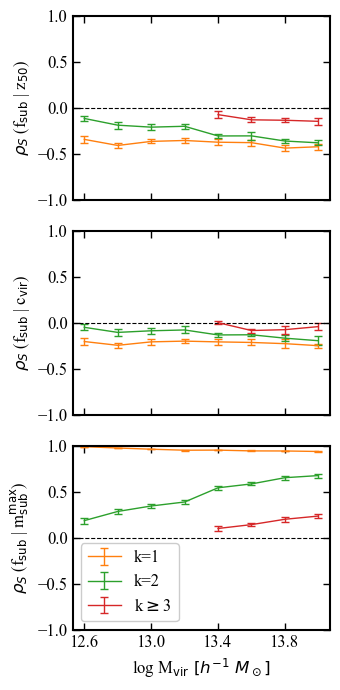

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(single_textwidth, double_textwidth), sharex=True, sharey=True)

datasets = [k1norm, k2norm, k3norm]
colors = ["C1", "C2", "C3"]
labelz = ["k=1", "k=2", "k$\geq$3"]

for j, dataset in enumerate(datasets):
    for i in range(3):
        axes[i].errorbar(
            dataset.logMvir_bincenters, dataset.rhofsub_mat[i], yerr=dataset.rhonorm_errfsub_mat[i], color=colors[j], capsize=3, lw=1, label=labelz[j])

axes[0].set_ylim(-1, 1)
axes[0].axhline(0, color="k", lw=0.8, ls="--")
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[2].axhline(0, color="k", lw=0.8, ls="--")
axes[2].set_xlabel("log M$_{\\rm vir}\ [h^{-1}\ M_\odot]$")

axes[0].set_ylabel("$\\rho_S$ (f$_{\\rm sub}$ | z$_{50}$)")
axes[1].set_ylabel("$\\rho_S$ (f$_{\\rm sub}$ | c$_{\\rm vir}$)")
axes[2].set_ylabel("$\\rho_S$ (f$_{\\rm sub}$ | m$_{\\rm sub}^{\\rm max}$)")

axes[2].set_xticks([12.6, 13.0, 13.4, 13.8])
axes[2].legend(framealpha=1, loc=3)
plt.tight_layout()
# plt.savefig("../../figures/rho_suborder_fsub.pdf", bbox_inches="tight")
plt.show()

In [13]:
bol_all = pd.read_csv("../../../misc/multidark/bolshoiP/BolshoiP_isolated_500.csv")

bol_k1 = jsm_ancillary.select_order(bol_all,k=1)

bol_k2 = jsm_ancillary.select_order(bol_all,k=2)

bol_k3 = jsm_ancillary.select_order(bol_all,k=3)

In [14]:
all_norm = jsm_simload.NormalizeData(bol_all, dataset_title="all")
k1_norm = jsm_simload.NormalizeData(bol_k1, dataset_title="k1")
k2_norm = jsm_simload.NormalizeData(bol_k2, dataset_title="k2")
k3_norm = jsm_simload.NormalizeData(bol_k3, dataset_title="k3")

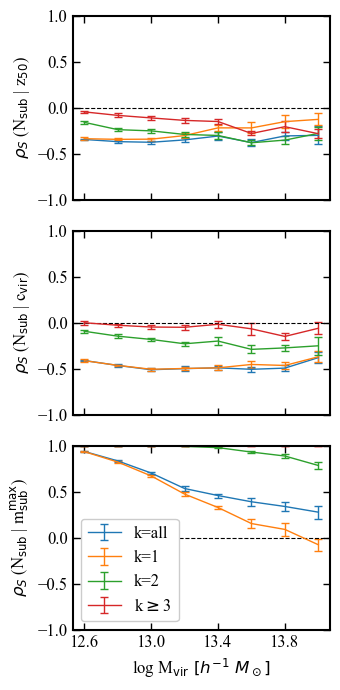

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(single_textwidth, double_textwidth), sharex=True, sharey=True)

datasets = [all_norm, k1_norm, k2_norm, k3_norm]
colors = ["C0", "C1", "C2", "C3"]
labelz = ["k=all", "k=1", "k=2", "k$\geq$3"]

for j, dataset in enumerate(datasets):
    for i in range(3):
        axes[i].errorbar(
            dataset.logMvir_bincenters, dataset.rho_mat[i], yerr=dataset.rho_err_mat[i], color=colors[j], capsize=3, lw=1, label=labelz[j])

axes[0].set_ylim(-1, 1)
axes[0].axhline(0, color="k", lw=0.8, ls="--")
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[2].axhline(0, color="k", lw=0.8, ls="--")
axes[2].set_xlabel("log M$_{\\rm vir}\ [h^{-1}\ M_\odot]$")

axes[0].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | z$_{50}$)")
axes[1].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | c$_{\\rm vir}$)")
axes[2].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | m$_{\\rm sub}^{\\rm max}$)")

axes[2].set_xticks([12.6, 13.0, 13.4, 13.8])
axes[2].legend(framealpha=1, loc=3)
plt.tight_layout()
# plt.savefig("../../figures/rho_suborder.pdf", bbox_inches="tight")
plt.show()

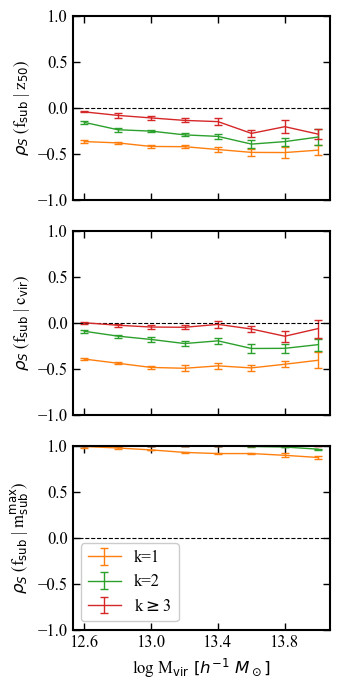

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(single_textwidth, double_textwidth), sharex=True, sharey=True)

datasets = [k1_norm, k2_norm, k3_norm]
colors = ["C1", "C2", "C3"]
labelz = ["k=1", "k=2", "k$\geq$3"]


for j, dataset in enumerate(datasets):
    for i in range(3):
        axes[i].errorbar(
            dataset.logMvir_bincenters, dataset.rhofsub_mat[i], yerr=dataset.rhonorm_errfsub_mat[i], color=colors[j], capsize=3, lw=1, label=labelz[j])

axes[0].set_ylim(-1, 1)
axes[0].axhline(0, color="k", lw=0.8, ls="--")
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[2].axhline(0, color="k", lw=0.8, ls="--")
axes[2].set_xlabel("log M$_{\\rm vir}\ [h^{-1}\ M_\odot]$")

axes[0].set_ylabel("$\\rho_S$ (f$_{\\rm sub}$ | z$_{50}$)")
axes[1].set_ylabel("$\\rho_S$ (f$_{\\rm sub}$ | c$_{\\rm vir}$)")
axes[2].set_ylabel("$\\rho_S$ (f$_{\\rm sub}$ | m$_{\\rm sub}^{\\rm max}$)")

axes[2].set_xticks([12.6, 13.0, 13.4, 13.8])
axes[2].legend(framealpha=1, loc=3)
plt.tight_layout()
# plt.savefig("../../figures/rho_suborder_fsub.pdf", bbox_inches="tight")
plt.show()

In [17]:
vsmdpl_all = pd.read_csv("../../../misc/multidark/vsmdpl/vsmdpl_isolated_500.csv")

vsmdpl_k1 = jsm_ancillary.select_order(vsmdpl_all,k=1)

vsmdpl_k2 = jsm_ancillary.select_order(vsmdpl_all,k=2)

vsmdpl_k3 = jsm_ancillary.select_order(vsmdpl_all,k=3)

In [21]:
all_norm = jsm_simload.NormalizeData(vsmdpl_all, dataset_title="all")
k1_norm = jsm_simload.NormalizeData(vsmdpl_k1, dataset_title="k1")
k2_norm = jsm_simload.NormalizeData(vsmdpl_k2, dataset_title="k2")
k3_norm = jsm_simload.NormalizeData(vsmdpl_k3, dataset_title="k3")

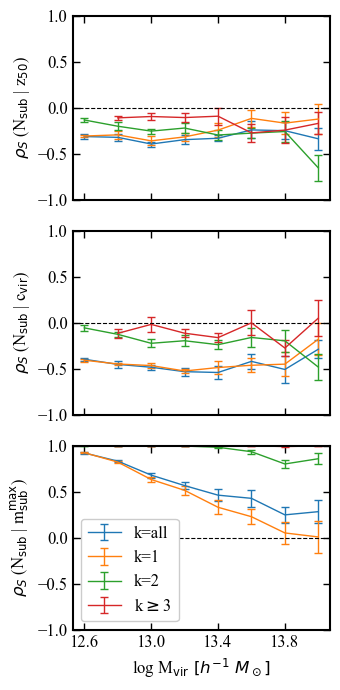

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(single_textwidth, double_textwidth), sharex=True, sharey=True)

datasets = [all_norm, k1_norm, k2_norm, k3_norm]
colors = ["C0", "C1", "C2", "C3"]
labelz = ["k=all", "k=1", "k=2", "k$\geq$3"]

for j, dataset in enumerate(datasets):
    for i in range(3):
        axes[i].errorbar(
            dataset.logMvir_bincenters, dataset.rho_mat[i], yerr=dataset.rho_err_mat[i], color=colors[j], capsize=3, lw=1, label=labelz[j])

axes[0].set_ylim(-1, 1)
axes[0].axhline(0, color="k", lw=0.8, ls="--")
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[2].axhline(0, color="k", lw=0.8, ls="--")
axes[2].set_xlabel("log M$_{\\rm vir}\ [h^{-1}\ M_\odot]$")

axes[0].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | z$_{50}$)")
axes[1].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | c$_{\\rm vir}$)")
axes[2].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | m$_{\\rm sub}^{\\rm max}$)")

axes[2].set_xticks([12.6, 13.0, 13.4, 13.8])
axes[2].legend(framealpha=1, loc=3)
plt.tight_layout()
# plt.savefig("../../figures/rho_suborder.pdf", bbox_inches="tight")
plt.show()

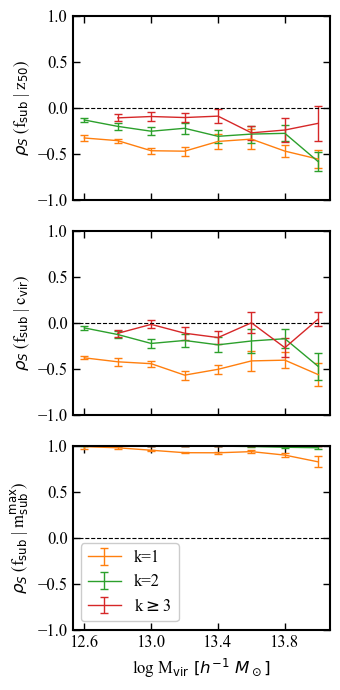

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(single_textwidth, double_textwidth), sharex=True, sharey=True)

datasets = [k1_norm, k2_norm, k3_norm]
colors = ["C1", "C2", "C3"]
labelz = ["k=1", "k=2", "k$\geq$3"]


for j, dataset in enumerate(datasets):
    for i in range(3):
        axes[i].errorbar(
            dataset.logMvir_bincenters, dataset.rhofsub_mat[i], yerr=dataset.rhonorm_errfsub_mat[i], color=colors[j], capsize=3, lw=1, label=labelz[j])

axes[0].set_ylim(-1, 1)
axes[0].axhline(0, color="k", lw=0.8, ls="--")
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[2].axhline(0, color="k", lw=0.8, ls="--")
axes[2].set_xlabel("log M$_{\\rm vir}\ [h^{-1}\ M_\odot]$")

axes[0].set_ylabel("$\\rho_S$ (f$_{\\rm sub}$ | z$_{50}$)")
axes[1].set_ylabel("$\\rho_S$ (f$_{\\rm sub}$ | c$_{\\rm vir}$)")
axes[2].set_ylabel("$\\rho_S$ (f$_{\\rm sub}$ | m$_{\\rm sub}^{\\rm max}$)")

axes[2].set_xticks([12.6, 13.0, 13.4, 13.8])
axes[2].legend(framealpha=1, loc=3)
plt.tight_layout()
# plt.savefig("../../figures/rho_suborder_fsub.pdf", bbox_inches="tight")
plt.show()